In [3]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
def langmuir_isotherm(P, Qmax, b):
    return (Qmax * b * P) / (1 + b * P)

In [5]:
# 读取CSV文件数据
files = {
    '283K': '吸附曲线用数据/fau-co2-283-1.csv',
    '298K': '吸附曲线用数据/fau-co2-298-1.csv',
    '323K': '吸附曲线用数据/fau-co2-323-1.csv',
    '348K': '吸附曲线用数据/fau-co2-348-1.csv'
}

# 定义拟合和绘图的函数
def fit_and_plot(data, temp_label):
    P = data['pressure'].values
    Q = data['adsorption (CURLTUGMZLYLDI-UHFFFAOYSA-N)'].values

    # Langmuir拟合
    popt, pcov = curve_fit(langmuir_isotherm, P, Q, bounds=(0, [np.inf, np.inf]))
    Qmax, b = popt
    Q_pred = langmuir_isotherm(P, Qmax, b)

    # 计算误差
    mean_error = np.mean(Q - Q_pred)
    max_error = max(abs(Q - Q_pred))
    relative_error = np.mean(np.abs((Q - Q_pred) / Q)) * 100
    mse = mean_squared_error(Q, Q_pred)
    r2 = r2_score(Q, Q_pred)

    # 输出拟合结果和误差
    print(f"{temp_label} Langmuir拟合参数: Qmax = {Qmax:.5f}, b = {b:.5f}")
    print(f"{temp_label} 平均误差: {mean_error:.5f}")
    print(f"{temp_label} 最大误差: {max_error:.5f}")
    print(f"{temp_label} 相对误差: {relative_error:.2f}%")
    print(f"{temp_label} MSE: {mse:.5f}")
    print(f"{temp_label} R²: {r2:.5f}")

    # 返回拟合曲线数据
    P_fine = np.linspace(min(P), max(P), 1000)
    Q_fine_pred = langmuir_isotherm(P_fine, Qmax, b)
    
    return P, Q, P_fine, Q_fine_pred

283K Langmuir拟合参数: Qmax = 5.30040, b = 103.10342
283K 平均误差: 0.16322
283K 最大误差: 0.96714
283K 相对误差: 37.84%
283K MSE: 0.17246
283K R²: 0.96451
298K Langmuir拟合参数: Qmax = 4.86198, b = 84.62294
298K 平均误差: 0.10987
298K 最大误差: 0.64659
298K 相对误差: 32.82%
298K MSE: 0.12373
298K R²: 0.96963
323K Langmuir拟合参数: Qmax = 4.26243, b = 27.56893
323K 平均误差: 0.07588
323K 最大误差: 0.49076
323K 相对误差: 27.77%
323K MSE: 0.06899
323K R²: 0.97511
348K Langmuir拟合参数: Qmax = 3.71782, b = 12.41568
348K 平均误差: 0.06020
348K 最大误差: 0.49017
348K 相对误差: 24.70%
348K MSE: 0.04165
348K R²: 0.97657


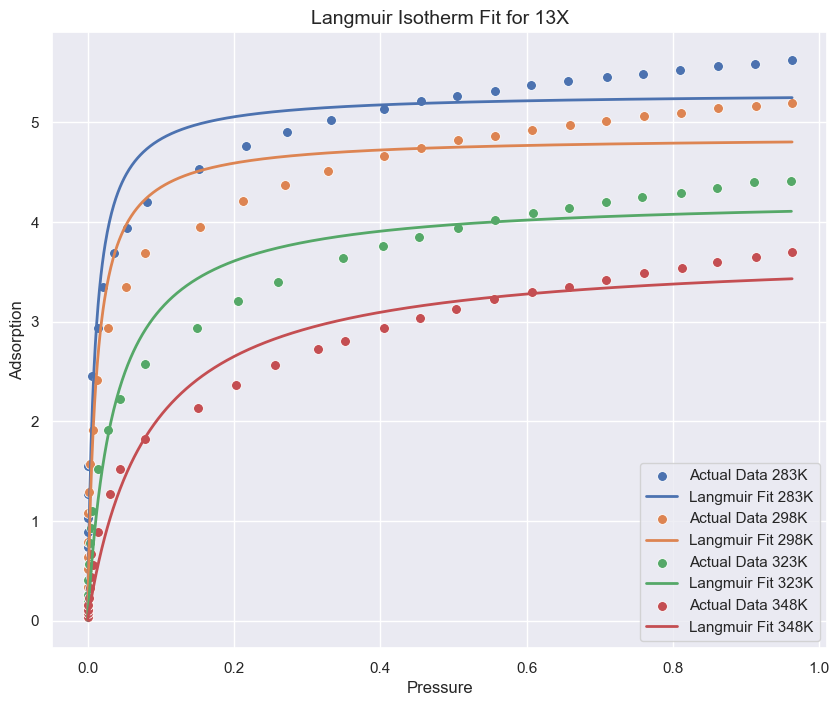

In [6]:
# 设置Seaborn的样式
sns.set(style="darkgrid")

# 整合多个数据文件
plt.figure(figsize=(10, 8))

# 循环处理所有文件并绘制
for temp_label, file in files.items():
    data = pd.read_csv(file)
    P, Q, P_fine, Q_fine_pred = fit_and_plot(data, temp_label)
    
    # 绘制实际数据点
    sns.scatterplot(x=P, y=Q, label=f'Actual Data {temp_label}', s=50)
    # 绘制拟合曲线
    sns.lineplot(x=P_fine, y=Q_fine_pred, label=f'Langmuir Fit {temp_label}', linewidth=2)

# 图形设置
# plt.xscale('log')  # 使用对数坐标轴
plt.xlabel('Pressure', fontsize=12)
plt.ylabel('Adsorption', fontsize=12)
plt.title('Langmuir Isotherm Fit for 13X', fontsize=14)
plt.legend()
plt.grid(True)

# 显示图形
plt.show()

In [7]:
files = {
    '298K': '吸附曲线用数据/stt-co2-298-1.csv',
    '323K': '吸附曲线用数据/stt-co2-323-1.csv',
    '348K': '吸附曲线用数据/stt-co2-348-1.csv'
}
# 双位点Sips模型定义
def dual_site_sips_isotherm(P, Qmax1, b1, n1, Qmax2, b2, n2):
    """
    双位点Sips模型: 结合两种吸附位点的Sips模型
    P: 压力
    Qmax1, b1, n1: 第一个吸附位点的Sips模型参数
    Qmax2, b2, n2: 第二个吸附位点的Sips模型参数
    """
    # Sips模型的形式为 (Qmax * (b * P)^n) / (1 + (b * P)^n)
    term1 = (Qmax1 * (b1 * P)**n1) / (1 + (b1 * P)**n1)
    term2 = (Qmax2 * (b2 * P)**n2) / (1 + (b2 * P)**n2)
    
    # 返回双位点的总吸附量
    return term1 + term2
# 定义拟合和绘图的函数
def fit_and_plot(data, temp_label):
    P = data['pressure'].values
    Q = data['adsorption (CURLTUGMZLYLDI-UHFFFAOYSA-N)'].values

    # 使用curve_fit拟合双位点Sips模型，初始参数需要提供6个
    initial_guess = [1.0, 0.01, 1.0, 1.0, 0.01, 1.0]
    popt, pcov = curve_fit(dual_site_sips_isotherm, P, Q, p0=initial_guess, bounds=(0, [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf]), maxfev=2000)
    
    Qmax1, b1, n1, Qmax2, b2, n2 = popt
    Q_pred = dual_site_sips_isotherm(P, Qmax1, b1, n1, Qmax2, b2, n2)

    # 计算误差
    mean_error = np.mean(Q - Q_pred)
    max_error = max(abs(Q - Q_pred))
    relative_error = np.mean(np.abs((Q - Q_pred) / Q)) * 100
    mse = mean_squared_error(Q, Q_pred)
    r2 = r2_score(Q, Q_pred)

    # 输出拟合结果和误差
    print(f"{temp_label} 双位点Sips拟合参数:")
    print(f"Qmax1 = {Qmax1:.5f}, b1 = {b1:.5f}, n1 = {n1:.5f}")
    print(f"Qmax2 = {Qmax2:.5f}, b2 = {b2:.5f}, n2 = {n2:.5f}")
    print(f"{temp_label} 平均误差: {mean_error:.5f}")
    print(f"{temp_label} 最大误差: {max_error:.5f}")
    print(f"{temp_label} 相对误差: {relative_error:.2f}%")
    print(f"{temp_label} MSE: {mse:.5f}")
    print(f"{temp_label} R²: {r2:.5f}")

    # 返回拟合曲线数据
    P_fine = np.linspace(min(P), max(P), 1000)
    Q_fine_pred = dual_site_sips_isotherm(P_fine, Qmax1, b1, n1, Qmax2, b2, n2)
    
    return P, Q, P_fine, Q_fine_pred

298K 双位点Sips拟合参数:
Qmax1 = 0.12444, b1 = 155.38647, n1 = 48.67672
Qmax2 = 8.35246, b2 = 0.24238, n2 = 0.78519
298K 平均误差: -0.00034
298K 最大误差: 0.02256
298K 相对误差: 5.95%
298K MSE: 0.00007
298K R²: 0.99988
323K 双位点Sips拟合参数:
Qmax1 = 2.99906, b1 = 0.52452, n1 = 0.75829
Qmax2 = 0.15651, b2 = 1.24569, n2 = 5.32973
323K 平均误差: 0.00010
323K 最大误差: 0.00750
323K 相对误差: 1.80%
323K MSE: 0.00002
323K R²: 0.99988
348K 双位点Sips拟合参数:
Qmax1 = 1.21910, b1 = 1.16827, n1 = 0.74655
Qmax2 = 1537.63508, b2 = 0.04007, n2 = 2.83102
348K 平均误差: 0.00019
348K 最大误差: 0.01264
348K 相对误差: 3.80%
348K MSE: 0.00006
348K R²: 0.99911


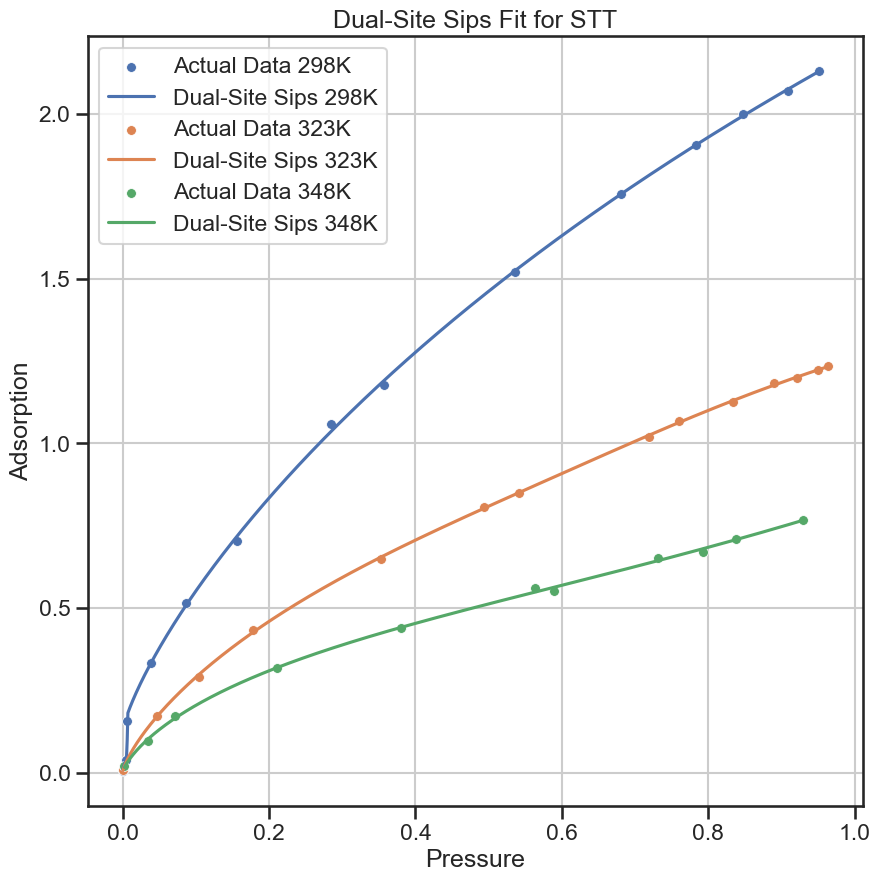

In [8]:
# 设置Seaborn的样式
sns.set(style="ticks")
sns.set_context('talk')

# 整合多个数据文件
plt.figure(figsize=(10, 10))

# 循环处理所有文件并绘制
for temp_label, file in files.items():
    data = pd.read_csv(file)
    P, Q, P_fine, Q_fine_pred = fit_and_plot(data, temp_label)
    
    # 绘制实际数据点
    sns.scatterplot(x=P, y=Q, label=f'Actual Data {temp_label}', s=50)
    # 绘制拟合曲线
    sns.lineplot(x=P_fine, y=Q_fine_pred, label=f'Dual-Site Sips {temp_label}')

# 图形设置
# plt.xscale('log')  # 使用对数坐标轴
plt.xlabel('Pressure')
plt.ylabel('Adsorption')
plt.title('Dual-Site Sips Fit for STT')
plt.legend()
plt.grid(True)

# 显示图形
plt.show()

283K Three-Site Langmuir拟合参数: Qmax1 = 2.04883, b1 = 2.05199, Qmax2 = 1.69089, b2 = 3380.26780, Qmax3 = 2.60409, b3 = 70.00394
283K 平均误差: -0.00168
283K 最大误差: 0.05473
283K 相对误差: 3.95%
283K MSE: 0.00026
283K R²: 0.99995
298K Three-Site Langmuir拟合参数: Qmax1 = 1.39606, b1 = 1655.02107, Qmax2 = 2.33746, b2 = 59.03525, Qmax3 = 2.35494, b3 = 1.86119
298K 平均误差: -0.00043
298K 最大误差: 0.07910
298K 相对误差: 1.72%
298K MSE: 0.00055
298K R²: 0.99987
323K Three-Site Langmuir拟合参数: Qmax1 = 3.00497, b1 = 2.09569, Qmax2 = 0.92156, b2 = 454.92089, Qmax3 = 1.52695, b3 = 52.05714
323K 平均误差: 0.00008
323K 最大误差: 0.03877
323K 相对误差: 0.97%
323K MSE: 0.00016
323K R²: 0.99994
348K Three-Site Langmuir拟合参数: Qmax1 = 0.49071, b1 = 262.03575, Qmax2 = 3.39008, b2 = 1.31870, Qmax3 = 1.34941, b3 = 37.31277
348K 平均误差: -0.00072
348K 最大误差: 0.21643
348K 相对误差: 4.64%
348K MSE: 0.00216
348K R²: 0.99879


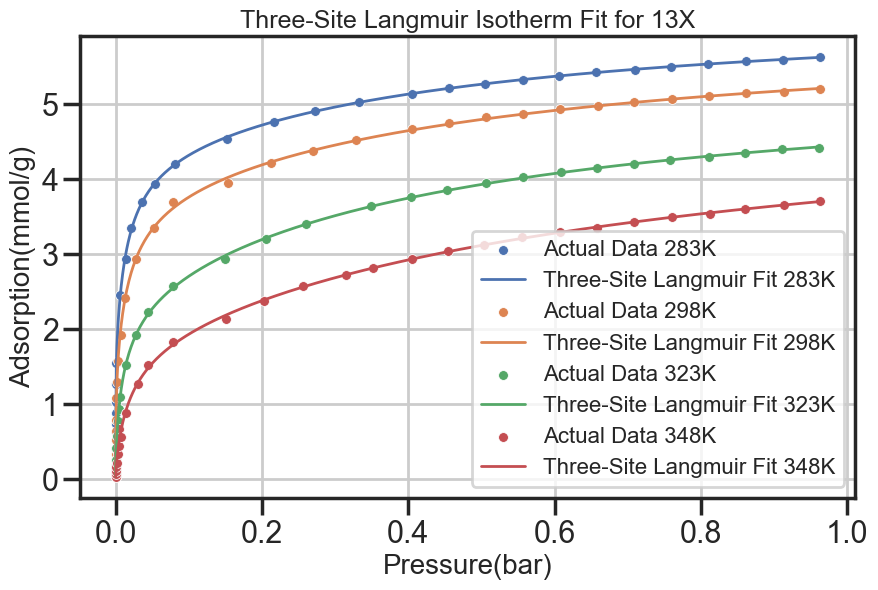

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, r2_score
# 定义Three-Site Langmuir模型
def three_site_langmuir_isotherm(P, Qmax1, b1, Qmax2, b2, Qmax3, b3):
    return ((Qmax1 * b1 * P) / (1 + b1 * P) +
            (Qmax2 * b2 * P) / (1 + b2 * P) +
            (Qmax3 * b3 * P) / (1 + b3 * P))

# 读取CSV文件数据
files = {
    '283K': '吸附曲线用数据/fau-co2-283-1.csv',
    '298K': '吸附曲线用数据/fau-co2-298-1.csv',
    '323K': '吸附曲线用数据/fau-co2-323-1.csv',
    '348K': '吸附曲线用数据/fau-co2-348-1.csv'
}

# 定义拟合和绘图的函数
def fit_and_plot(data, temp_label):
    P = data['pressure'].values
    Q = data['adsorption (CURLTUGMZLYLDI-UHFFFAOYSA-N)'].values

    # Three-Site Langmuir拟合
    popt, pcov = curve_fit(three_site_langmuir_isotherm, P, Q, bounds=(0, [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf]))
    Qmax1, b1, Qmax2, b2, Qmax3, b3 = popt
    Q_pred = three_site_langmuir_isotherm(P, Qmax1, b1, Qmax2, b2, Qmax3, b3)

    # 计算误差
    mean_error = np.mean(Q - Q_pred)
    max_error = max(abs(Q - Q_pred))
    relative_error = np.mean(np.abs((Q - Q_pred) / Q)) * 100
    mse = mean_squared_error(Q, Q_pred)
    r2 = r2_score(Q, Q_pred)

    # 输出拟合结果和误差
    print(f"{temp_label} Three-Site Langmuir拟合参数: Qmax1 = {Qmax1:.5f}, b1 = {b1:.5f}, Qmax2 = {Qmax2:.5f}, b2 = {b2:.5f}, Qmax3 = {Qmax3:.5f}, b3 = {b3:.5f}")
    print(f"{temp_label} 平均误差: {mean_error:.5f}")
    print(f"{temp_label} 最大误差: {max_error:.5f}")
    print(f"{temp_label} 相对误差: {relative_error:.2f}%")
    print(f"{temp_label} MSE: {mse:.5f}")
    print(f"{temp_label} R²: {r2:.5f}")

    # 返回拟合曲线数据
    P_fine = np.linspace(min(P), max(P), 1000)
    Q_fine_pred = three_site_langmuir_isotherm(P_fine, Qmax1, b1, Qmax2, b2, Qmax3, b3)
    
    return P, Q, P_fine, Q_fine_pred

# 设置Seaborn的样式
sns.set(style="ticks")
sns.set_context('poster')

# 整合多个数据文件
plt.figure(figsize=(10, 6))

# 循环处理所有文件并绘制
for temp_label, file in files.items():
    data = pd.read_csv(file)
    P, Q, P_fine, Q_fine_pred = fit_and_plot(data, temp_label)
    
    # 绘制实际数据点
    sns.scatterplot(x=P, y=Q, label=f'Actual Data {temp_label}', s=50)
    # 绘制拟合曲线
    sns.lineplot(x=P_fine, y=Q_fine_pred, label=f'Three-Site Langmuir Fit {temp_label}', linewidth=2)

# 图形设置
# plt.xscale('log')  # 使用对数坐标轴
plt.xlabel('Pressure(bar)', fontsize=20)
plt.ylabel('Adsorption(mmol/g)', fontsize=20)
plt.title('Three-Site Langmuir Isotherm Fit for 13X', fontsize=18)
plt.legend(fontsize=16)
plt.grid(True)

# 显示图形
plt.show()

C:\Users\赵芃\AppData\Local\Temp\ipykernel_34360\1728622540.py:24: RuntimeWarning: overflow encountered in exp
  return qm * (P_kPa * (ba * np.exp(Qa / (gs * T)))) / ((1 + ((ba * np.exp(Qa / (gs * T))) * P_kPa) ** t0) ** (1 / t0))
C:\Users\赵芃\AppData\Local\Temp\ipykernel_34360\1728622540.py:24: RuntimeWarning: invalid value encountered in divide
  return qm * (P_kPa * (ba * np.exp(Qa / (gs * T)))) / ((1 + ((ba * np.exp(Qa / (gs * T))) * P_kPa) ** t0) ** (1 / t0))
C:\Users\赵芃\AppData\Local\Temp\ipykernel_34360\1728622540.py:24: RuntimeWarning: overflow encountered in power
  return qm * (P_kPa * (ba * np.exp(Qa / (gs * T)))) / ((1 + ((ba * np.exp(Qa / (gs * T))) * P_kPa) ** t0) ** (1 / t0))


全局拟合参数: ba = 2.6814995266088004e-05, Qa = 387.0604894699586, t0 = 0.3034544757809943, qm = 7.273305371396823
283K 拟合结果: ba = 0.00003, Qa = 387.06049, t0 = 0.30345, qm = 7.27331
283K 平均误差: -0.01059
283K 最大误差: 0.14969
283K 相对误差: 13.87%
283K MSE: 0.00442
283K R²: 0.99909
298K 拟合结果: ba = 0.00003, Qa = 387.06049, t0 = 0.30345, qm = 7.27331
298K 平均误差: 0.01692
298K 最大误差: 0.12876
298K 相对误差: 9.85%
298K MSE: 0.00329
298K R²: 0.99919
323K 拟合结果: ba = 0.00003, Qa = 387.06049, t0 = 0.30345, qm = 7.27331
323K 平均误差: -0.02209
323K 最大误差: 0.15468
323K 相对误差: 12.89%
323K MSE: 0.00343
323K R²: 0.99876
348K 拟合结果: ba = 0.00003, Qa = 387.06049, t0 = 0.30345, qm = 7.27331
348K 平均误差: -0.00827
348K 最大误差: 0.17441
348K 相对误差: 14.25%
348K MSE: 0.00623
348K R²: 0.99650


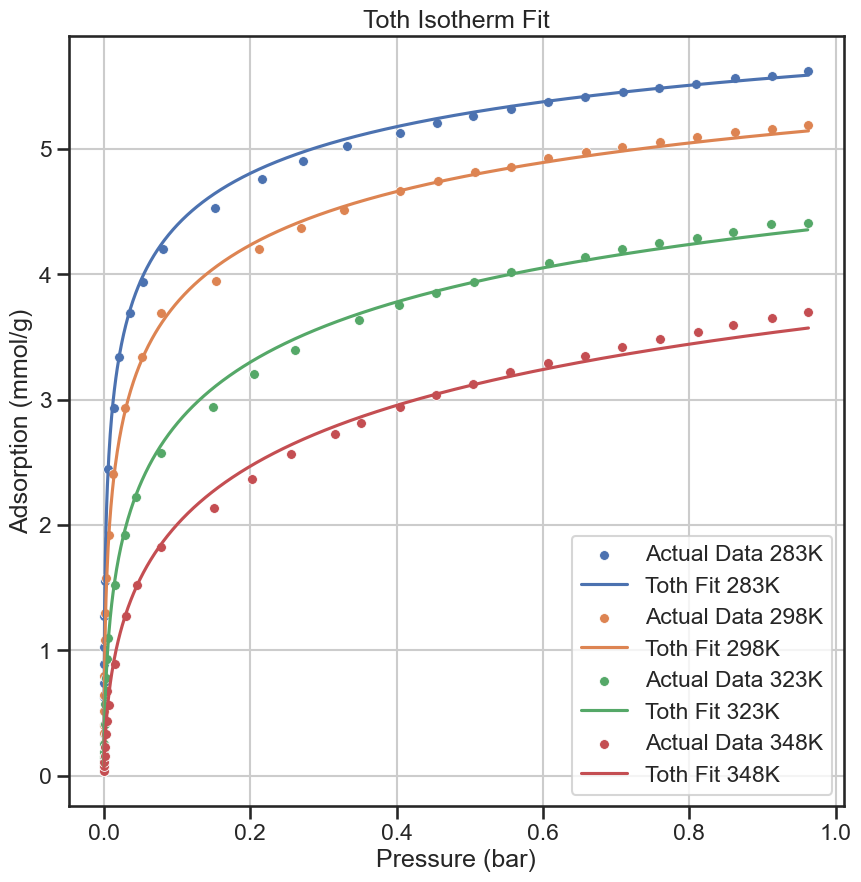

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import re
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score

# 固定值：气体常数
gs = 0.0729019027
sns.set(style="ticks")
sns.set_context('talk')
# 定义托斯吸附等温线模型
def toth_isotherm(P_kPa, ba, Qa, t0, qm, T):
    """
    托斯等温线模型，计算不同压力下的吸附量。
    P_kPa: 压力
    ba: 吸附平衡常数
    Qa: 吸附能
    t0: 等温线的指数参数
    qm: 最大吸附量
    T: 温度
    """
    return qm * (P_kPa * (ba * np.exp(Qa / (gs * T)))) / ((1 + ((ba * np.exp(Qa / (gs * T))) * P_kPa) ** t0) ** (1 / t0))

# 定义拟合和绘图函数，处理多个温度的数据
def fit_and_plot_multiple_temps(files):
    """
    对多个温度的数据进行拟合，并绘制结果。
    files: 一个包含多个温度数据的字典，键为温度标签，值为对应的数据文件路径
    """
    plt.figure(figsize=(10, 10))

    all_P = []
    all_q_e = []
    all_T = []

    # 循环读取每个温度的数据文件
    for temp_label, file in files.items():
        data = pd.read_csv(file)
        P_kPa = data['pressure'].values
        q_e = data['adsorption (CURLTUGMZLYLDI-UHFFFAOYSA-N)'].values
        T = np.full_like(P_kPa, int(re.sub('[K]', '', temp_label)))  # 提取温度
        
        all_P.extend(P_kPa)
        all_q_e.extend(q_e)
        all_T.extend(T)

    # 转换为数组
    all_P = np.array(all_P)
    all_q_e = np.array(all_q_e)
    all_T = np.array(all_T)

    # 初始猜测值
    initial_guess_global = [0.000001, 100, 10, 0.1]  # ba, Qa, t0, qm的初始猜测值
    bounds = (-np.inf, np.inf)

    # 对所有温度的数据进行拟合
    popt_global, _ = curve_fit(lambda P_T, ba, Qa, t0, qm: toth_isotherm(P_T[0], ba, Qa, t0, qm, P_T[1]), 
                               (all_P, all_T), all_q_e, p0=initial_guess_global, bounds=bounds, maxfev=80000)

    # 输出全局拟合参数
    ba, Qa, t0, qm = popt_global
    print(f"全局拟合参数: ba = {ba}, Qa = {Qa}, t0 = {t0}, qm = {qm}")

    # 单独处理每个温度的数据并计算误差
    for temp_label, file in files.items():
        data = pd.read_csv(file)
        P_kPa = data['pressure'].values
        q_e = data['adsorption (CURLTUGMZLYLDI-UHFFFAOYSA-N)'].values
        T = int(re.sub('[K]', '', temp_label))

        # 计算拟合曲线
        P_fine = np.linspace(min(P_kPa), max(P_kPa), 1000)
        q_e_fine_pred = toth_isotherm(P_fine, ba, Qa, t0, qm, T)
        q_e_pred = toth_isotherm(P_kPa, ba, Qa, t0, qm, T)

        # 计算误差
        mean_error = np.mean(q_e - q_e_pred)
        max_error = np.max(np.abs(q_e - q_e_pred))
        relative_error = np.mean(np.abs((q_e - q_e_pred) / q_e)) * 100
        mse = mean_squared_error(q_e, q_e_pred)
        r2 = r2_score(q_e, q_e_pred)

        # 输出拟合结果和误差
        print(f"{temp_label} 拟合结果: ba = {ba:.5f}, Qa = {Qa:.5f}, t0 = {t0:.5f}, qm = {qm:.5f}")
        print(f"{temp_label} 平均误差: {mean_error:.5f}")
        print(f"{temp_label} 最大误差: {max_error:.5f}")
        print(f"{temp_label} 相对误差: {relative_error:.2f}%")
        print(f"{temp_label} MSE: {mse:.5f}")
        print(f"{temp_label} R²: {r2:.5f}")

        # 绘制实际数据点
        sns.scatterplot(x=P_kPa, y=q_e, label=f'Actual Data {temp_label}', s=50)
        # 绘制拟合曲线
        sns.lineplot(x=P_fine, y=q_e_fine_pred, label=f'Toth Fit {temp_label}')

    # 设置图表样式
    plt.xlabel('Pressure (bar)')
    plt.ylabel('Adsorption (mmol/g)')
    plt.title('Toth Isotherm Fit')
    plt.legend()
    plt.grid(True)
    plt.show()

# 读取CSV文件数据
files = {
    '283K': '吸附曲线用数据/fau-co2-283-1.csv',
    '298K': '吸附曲线用数据/fau-co2-298-1.csv',
    '323K': '吸附曲线用数据/fau-co2-323-1.csv',
    '348K': '吸附曲线用数据/fau-co2-348-1.csv'
}

# 执行拟合和绘图
fit_and_plot_multiple_temps(files)


In [3]:

file = r'C:\ProgramData\AMD\PPC\metrics.csv'
with open(file, mode='r') as f:
    head = [f.readline() for _ in range(10)]
    

In [4]:
head

['28C26504-2C7A-40D4-A610-E765CB263EFB,5725.00,ac,i,132696207278300000,0,False,True,sihost.exe@3332^5046^30613504^2203494182912^8298496^10|svchost.exe@3356^3750^27189248^2203476664320^13381632^6|svchost.exe@3460^4359^46657536^2203527761920^9814016^6|AUEPMaster.exe@3604^250140^99770368^4863762432^381591552^6|taskhostw.exe@3776^750^18735104^2203596505088^7565312^8|ctfmon.exe@4000^7343^49684480^2203603234816^15925248^13|wallpaper32.exe@5052^47703^104738816^488841216^133165056^41|ChsIME.exe@5392^31^8192000^2203415359488^1499136^2|explorer.exe@5860^130968^196550656^2204231897088^182366208^114|spacedeskServiceTray.exe@5992^2062^22638592^142839808^3473408^4|GroupyCtrl.exe@6028^23656^38043648^2203511087104^21913600^9|TabTip.exe@6724^1062^17989632^2203501432832^4268032^6|svchost.exe@7432^140^22462464^2203484647424^4046848^5|StartMenuExperienceHost.exe@8476^1468^71225344^2203783675904^31481856^9|RuntimeBroker.exe@8604^2265^26021888^2203473666048^6373376^1|SearchApp.exe@8872^7593^102432768^223876

In [5]:
from pathlib import Path
Path('./aaa.csv').write_text('\n'.join(head))

70252

In [6]:
import pandas as pd
pd.read_csv('aaa.csv')

28C26504-2C7A-40D4-A610-E765CB263EFB  5725.00  ac  i  132696207278300000   
0  28C26504-2C7A-40D4-A610-E765CB263EFB   5702.0  ac  i  132696207335320000  \
1  28C26504-2C7A-40D4-A610-E765CB263EFB   5766.0  ac  i  132696207392980000   
2  28C26504-2C7A-40D4-A610-E765CB263EFB   5735.0  ac  i  132696207450330000   
3  28C26504-2C7A-40D4-A610-E765CB263EFB   5743.0  ac  i  132696207507760000   
4  28C26504-2C7A-40D4-A610-E765CB263EFB   5742.0  ac  i  132696207565180000   
5  28C26504-2C7A-40D4-A610-E765CB263EFB   5754.0  ac  i  132696207622720000   
6  28C26504-2C7A-40D4-A610-E765CB263EFB   5756.0  ac  i  132696207680280000   
7  28C26504-2C7A-40D4-A610-E765CB263EFB   5805.0  ac  i  132696207738330000   
8  28C26504-2C7A-40D4-A610-E765CB263EFB   5760.0  ac  i  132696207795930000   

   0  False  True   
0  5  False  True  \
1  1  False  True   
2  0  False  True   
3  0  False  True   
4  0  False  True   
5  1  False  True   
6  0  False  True   
7  1  False  True   
8  0  False  True   

  sihost.exe@3332^5046^30613504^2203494182912^8298496^10|svchost.exe@3356^3750^27189248^2203476664320^13381632^6|svchost.exe@3460^4359^46657536^2203527761920^9814016^6|AUEPMaster.exe@3604^250140^99770368^4863762432^381591552^6|taskhostw.exe@3776^750^18735104^2203596505088^7565312^8|ctfmon.exe@4000^7343^49684480^2203603234816^15925248^13|wallpaper32.exe@5052^47703^104738816^488841216^133165056^41|ChsIME.exe@5392^31^8192000^2203415359488^1499136^2|explorer.exe@5860^130968^196550656^2204231897088^182366208^114|spacedeskServiceTray.exe@5992^2062^22638592^142839808^3473408^4|GroupyCtrl.exe@6028^23656^38043648^2203511087104^21913600^9|TabTip.exe@6724^1062^17989632^2203501432832^4268032^6|svchost.exe@7432^140^22462464^2203484647424^4046848^5|StartMenuExperienceHost.exe@8476^1468^71225344^2203783675904^31481856^9|RuntimeBroker.exe@8604^2265^26021888^2203473666048^6373376^1|SearchApp.exe@8872^7593^102432768^2238765826048^112082944^46|RuntimeBroker.exe@9164^4593^33333248^2203523596288^9424896^8|YourPhone.exe@9564^500^2080768^5143097344^25645056^15|SettingSyncHost.exe@9628^1203^6520832^2203476635648^6123520^3|RuntimeBroker.exe@9724^10437^26275840^2203488661504^7225344^1|LockApp.exe@10300^625^42782720^2203748761600^16982016^16|RuntimeBroker.exe@10596^843^31875072^2203509866496^9232384^7|svchost.exe@7664^390^19431424^2203724709888^5496832^6|TextInputHost.exe@2008^7062^58159104^2203722301440^21463040^18|RuntimeBroker.exe@4368^234^20852736^2203462922240^4653056^4|SecurityHealthSystray.exe@1464^93^10035200^2203429171200^2052096^1|vgtray.exe@11340^46^8282112^4415762432^1527808^2|OneDrive.exe@11612^11453^55750656^420622336^82477056^26|steam.exe@11568^187343^78630912^495669248^112529408^28|Razer Synapse Service Process.exe@12092^11328^51830784^358670336^33935360^26|Listary.exe@11724^1500^36470784^214831104^75157504^12|WeChat.exe@3836^72421^127344640^459235328^98664448^46|yundetectservice.exe@1804^62^13385728^109588480^5173248^12|ListaryHelper64.exe@11760^15^6561792^4384944128^1294336^2|ListaryHookHelper32.exe@12292^28578^7405568^51699712^1236992^1|ListaryHookHelper64.exe@12324^46^7823360^4404248576^1552384^1|ONENOTEM.EXE@12596^93^3485696^2203439529984^2764800^2|SunloginClient.exe@12628^9703^48889856^310419456^86233088^23|ShellExperienceHost.exe@12664^5265^79781888^2203824705536^35672064^26|RuntimeBroker.exe@13084^468^32153600^2203520446464^7430144^10|WeChatPlayer.exe@12404^296^16388096^140713984^16834560^16|WechatBrowser.exe@1360^6843^57405440^405241856^30130176^24|WechatBrowser.exe@10960^640^75755520^490844160^113594368^22|WechatBrowser.exe@5512^187^22941696^247332864^10260480^8|svchost.exe@13484^15^8704000^2203419209728^1781760^1|SystemSettingsBroker.exe@13592^781^17068032^2203443601408^4513792^3|steamwebhelper.exe@14328^33234^52031488^4740321280^21852160^17|steamwebhelper.exe@12496^93^15425536^4596531200^7970816^6|steamwebhelper.exe@4980^437^50585600^4824682496^53968896^23|steamwebhelper.exe@1072^375^26075136^4618481664^11198464^8|cpumetricsserver.exe@13856^62^31